# ARTI 404 - Image Denoising Using Spatial and Frequency Domain Methods

**Student Name:** Faisal Alzahrani  
**Course:** ARTI 404 - Image Processing  
**Assignment:** Image Denoising Using Spatial and Frequency Domain Methods  

## Notebook objective
This notebook follows the provided starter code structure and completes the assignment requirements:

1. Load clean and noisy images from `dataset/clean` and `dataset/noisy`.
2. Identify likely noise type for every noisy image.
3. Implement a spatial-domain denoising method.
4. Implement Gaussian Low-Pass Filtering in the frequency domain using the Fourier Transform.
5. Tune at least three parameter settings for each method.
6. Evaluate the denoising results using PSNR and SSIM.
7. Display results, save outputs, and generate CSV result tables.


In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Make plots clean and readable
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = False

# -------------------------
# Dataset setup
# -------------------------
DATASET = Path("dataset")
CLEAN_DIR = DATASET / "clean"
NOISY_DIR = DATASET / "noisy"
RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

image_names = [
    "camera",
    "coins",
    "text",
    "rice",
    "astronaut"
]

print("Dataset folder:", DATASET.resolve())
print("Images:", image_names)


Dataset folder: C:\Users\faisa\Desktop\ARTI404_Denoising_Enhanced_Submission\dataset
Images: ['camera', 'coins', 'text', 'rice', 'astronaut']


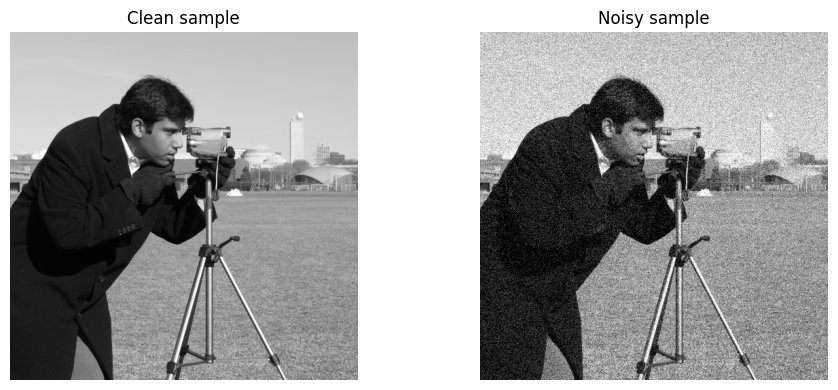

In [2]:
# -------------------------
# Load image
# -------------------------
def load_image(path):
    """Load an image with OpenCV and convert BGR to RGB when needed."""
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")

    # Convert OpenCV BGR to RGB for color images
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img


def save_image(path, img):
    """Save grayscale/RGB image correctly using OpenCV."""
    path = Path(path)
    if img.ndim == 3:
        cv2.imwrite(str(path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    else:
        cv2.imwrite(str(path), img)


def show_image(img, title="Image"):
    """Display one image."""
    cmap = "gray" if img.ndim == 2 else None
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


# Quick test: show one clean/noisy pair
sample_name = "camera"
clean_sample = load_image(CLEAN_DIR / f"{sample_name}.png")
noisy_sample = load_image(NOISY_DIR / f"{sample_name}_noisy.png")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(clean_sample, cmap="gray" if clean_sample.ndim == 2 else None)
plt.title("Clean sample")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_sample, cmap="gray" if noisy_sample.ndim == 2 else None)
plt.title("Noisy sample")
plt.axis("off")
plt.tight_layout()
plt.show()


In [3]:
# -------------------------
# Evaluation metrics
# -------------------------
def evaluate(clean, denoised):
    """Return PSNR and SSIM between clean reference and denoised image."""
    if clean.shape != denoised.shape:
        denoised = cv2.resize(denoised, (clean.shape[1], clean.shape[0]))

    psnr_value = psnr(clean, denoised, data_range=255)

    if len(clean.shape) == 3:
        ssim_value = ssim(clean, denoised, channel_axis=-1, data_range=255)
    else:
        ssim_value = ssim(clean, denoised, data_range=255)

    return float(psnr_value), float(ssim_value)


# Baseline noisy quality before denoising
baseline_rows = []
for name in image_names:
    clean = load_image(CLEAN_DIR / f"{name}.png")
    noisy = load_image(NOISY_DIR / f"{name}_noisy.png")
    p, s = evaluate(clean, noisy)
    baseline_rows.append([name, p, s])

baseline_df = pd.DataFrame(baseline_rows, columns=["Image", "Noisy PSNR", "Noisy SSIM"])
baseline_df


,Image,Noisy PSNR,Noisy SSIM
0,camera,20.419341,0.295099
1,coins,16.140071,0.307930
2,text,15.053239,0.168096
3,rice,17.386880,0.294051
4,astronaut,14.560049,0.242411


## Part 1 - Noise analysis

The following table records the most likely noise type for each image. The clean images are used only for evaluation, not as an input to the denoising methods.


In [4]:
noise_analysis = {
    "camera": {
        "Likely Noise Type": "Gaussian noise",
        "Justification": "Fine grain appears across the full image with random intensity variation."
    },
    "coins": {
        "Likely Noise Type": "Salt-and-pepper / impulse noise",
        "Justification": "Many isolated bright and dark dots appear on the coins and the background."
    },
    "text": {
        "Likely Noise Type": "Salt-and-pepper noise",
        "Justification": "Random black and white pixels are scattered over the paper and writing."
    },
    "rice": {
        "Likely Noise Type": "Salt-and-pepper noise",
        "Justification": "The image contains isolated white and dark pixel corruption over the textured background."
    },
    "astronaut": {
        "Likely Noise Type": "Colored salt-and-pepper / impulse noise",
        "Justification": "Random colored pixels affect the RGB channels, especially visible in smooth areas."
    }
}

noise_df = pd.DataFrame([
    {"Image": name, **noise_analysis[name]} for name in image_names
])
noise_df


,Image,Likely Noise Type,Justification
0,camera,Gaussian noise,Fine grain appears across the full image with ...
1,coins,Salt-and-pepper / impulse noise,Many isolated bright and dark dots appear on t...
2,text,Salt-and-pepper noise,Random black and white pixels are scattered ov...
3,rice,Salt-and-pepper noise,The image contains isolated white and dark pix...
4,astronaut,Colored salt-and-pepper / impulse noise,"Random colored pixels affect the RGB channels,..."


## Part 2 - Denoising methods

### Method 1: Spatial-domain filtering
The selected spatial-domain method is **median filtering**. Median filtering is suitable for impulse and salt-and-pepper noise because it replaces each pixel with the median value inside the local neighborhood. This removes isolated corrupted pixels while preserving edges better than simple averaging.

### Method 2: Frequency-domain Gaussian Low-Pass Filter
The second method uses the Fourier Transform. The image is transformed into the frequency domain, a Gaussian low-pass filter is applied, and then the inverse Fourier Transform is used to reconstruct the denoised image.


In [5]:
# -------------------------
# Method 1: Spatial-domain denoising
# -------------------------
def spatial_denoising(img, method="median", kernel_size=5):
    """
    Spatial-domain denoising method.

    Selected method for this assignment: median filter.
    Other options are kept for experimentation and comparison.
    """
    if kernel_size % 2 == 0:
        kernel_size += 1

    if method == "median":
        return cv2.medianBlur(img, kernel_size)

    elif method == "gaussian":
        return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

    elif method == "mean":
        return cv2.blur(img, (kernel_size, kernel_size))

    elif method == "bilateral":
        return cv2.bilateralFilter(img, d=kernel_size, sigmaColor=75, sigmaSpace=75)

    else:
        raise ValueError("Unknown spatial method selected.")


# -------------------------
# Method 2: Frequency-domain Gaussian low-pass filter
# -------------------------
def gaussian_lowpass_filter(shape, cutoff):
    """
    Create a Gaussian low-pass filter.

    shape: image shape for a grayscale image
    cutoff: controls the amount of smoothing
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    u = np.arange(rows)
    v = np.arange(cols)
    V, U = np.meshgrid(v, u)

    distance_squared = (U - crow) ** 2 + (V - ccol) ** 2
    H = np.exp(-distance_squared / (2 * cutoff ** 2))

    return H


def frequency_gaussian_denoising_gray(img_gray, cutoff=40):
    """Apply Gaussian low-pass filtering in the frequency domain to one channel."""
    img_float = img_gray.astype(np.float32)

    # Fourier transform
    F = np.fft.fft2(img_float)

    # Shift zero frequency to center
    F_shifted = np.fft.fftshift(F)

    # Create Gaussian low-pass filter
    H = gaussian_lowpass_filter(img_gray.shape, cutoff)

    # Apply filter in frequency domain
    G_shifted = F_shifted * H

    # Shift back
    G = np.fft.ifftshift(G_shifted)

    # Inverse Fourier transform
    img_filtered = np.fft.ifft2(G)

    # Keep real part and clip values
    img_filtered = np.real(img_filtered)
    img_filtered = np.clip(img_filtered, 0, 255)

    return img_filtered.astype(np.uint8)


def frequency_gaussian_denoising(img, cutoff=40):
    """
    Apply Gaussian low-pass filtering in the frequency domain.
    Works for both grayscale and RGB images.
    """
    if len(img.shape) == 2:
        return frequency_gaussian_denoising_gray(img, cutoff)

    channels = []
    for c in range(img.shape[2]):
        filtered_channel = frequency_gaussian_denoising_gray(img[:, :, c], cutoff)
        channels.append(filtered_channel)

    return np.stack(channels, axis=2)


## Part 3 - Parameter tuning

The assignment requires testing at least three parameter settings for each method. This notebook tests four settings for each method:

- Spatial median filter kernel sizes: `3x3`, `5x5`, `7x7`, `9x9`
- Frequency Gaussian LPF cutoffs: `10`, `20`, `40`, `80`

The best configuration is selected based on the highest SSIM because SSIM measures structural similarity and is usually more meaningful visually than PSNR alone.



Processing image: camera
Spatial median, kernel=3: PSNR=25.71, SSIM=0.4939
Spatial median, kernel=5: PSNR=26.21, SSIM=0.6040
Spatial median, kernel=7: PSNR=25.48, SSIM=0.6442
Spatial median, kernel=9: PSNR=24.41, SSIM=0.6469
Frequency Gaussian, cutoff=10: PSNR=20.54, SSIM=0.5714
Frequency Gaussian, cutoff=20: PSNR=22.57, SSIM=0.6268
Frequency Gaussian, cutoff=40: PSNR=25.04, SSIM=0.6879
Frequency Gaussian, cutoff=80: PSNR=26.94, SSIM=0.6403


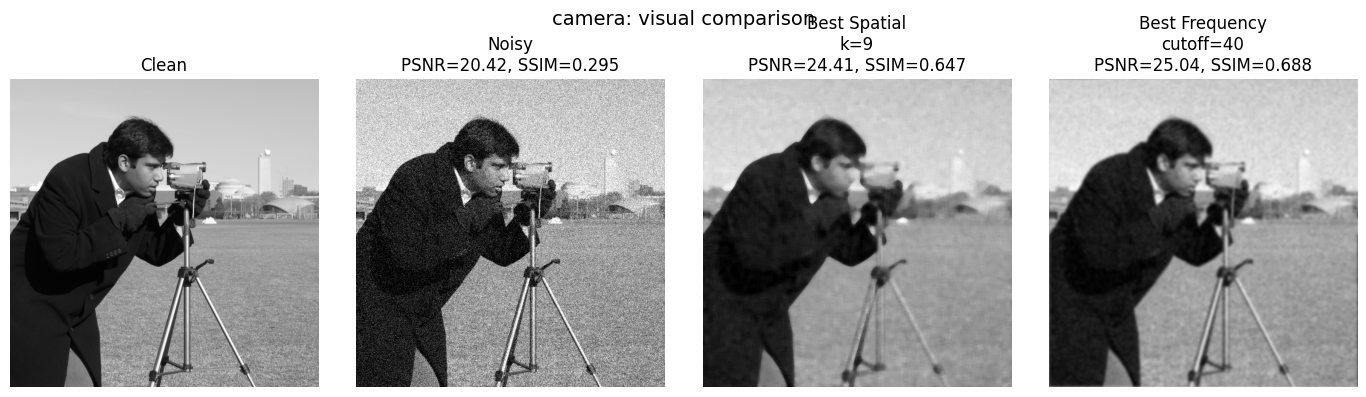


Processing image: coins
Spatial median, kernel=3: PSNR=28.07, SSIM=0.8536
Spatial median, kernel=5: PSNR=26.17, SSIM=0.7710
Spatial median, kernel=7: PSNR=25.12, SSIM=0.7262
Spatial median, kernel=9: PSNR=24.30, SSIM=0.6936
Frequency Gaussian, cutoff=10: PSNR=19.40, SSIM=0.4628
Frequency Gaussian, cutoff=20: PSNR=21.61, SSIM=0.5585
Frequency Gaussian, cutoff=40: PSNR=23.38, SSIM=0.5748
Frequency Gaussian, cutoff=80: PSNR=22.50, SSIM=0.4816


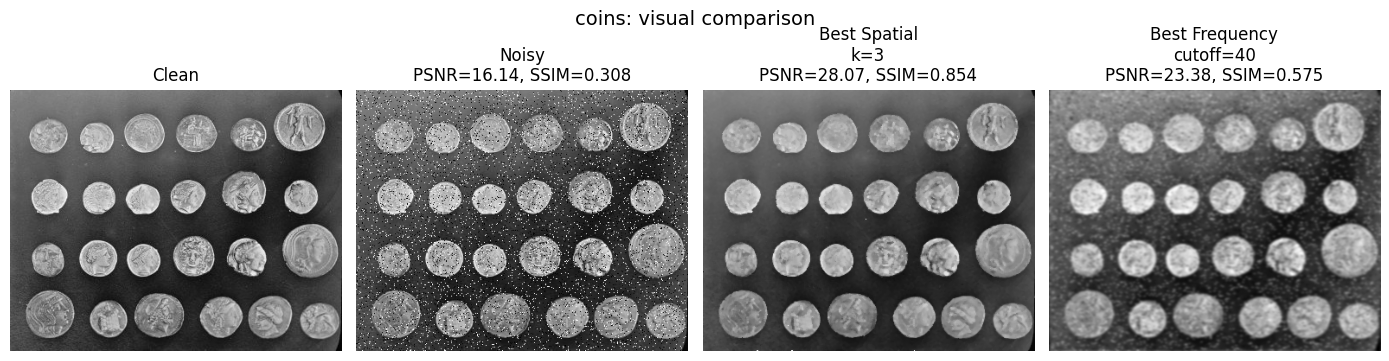


Processing image: text
Spatial median, kernel=3: PSNR=32.01, SSIM=0.9043
Spatial median, kernel=5: PSNR=28.51, SSIM=0.8240
Spatial median, kernel=7: PSNR=25.48, SSIM=0.7166
Spatial median, kernel=9: PSNR=23.76, SSIM=0.6270
Frequency Gaussian, cutoff=10: PSNR=23.71, SSIM=0.5779
Frequency Gaussian, cutoff=20: PSNR=25.59, SSIM=0.6524
Frequency Gaussian, cutoff=40: PSNR=25.33, SSIM=0.5466
Frequency Gaussian, cutoff=80: PSNR=21.26, SSIM=0.3501


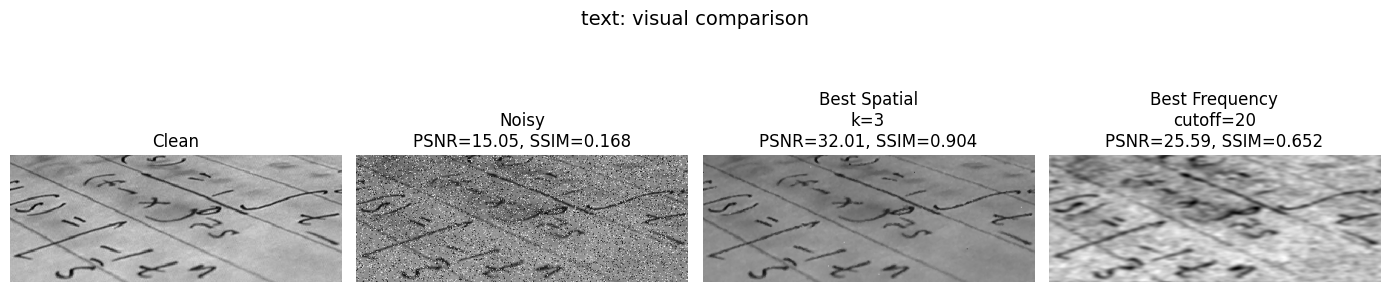


Processing image: rice
Spatial median, kernel=3: PSNR=23.03, SSIM=0.4602
Spatial median, kernel=5: PSNR=23.78, SSIM=0.5393
Spatial median, kernel=7: PSNR=23.34, SSIM=0.5659
Spatial median, kernel=9: PSNR=22.75, SSIM=0.5644
Frequency Gaussian, cutoff=10: PSNR=19.69, SSIM=0.4630
Frequency Gaussian, cutoff=20: PSNR=22.02, SSIM=0.5731
Frequency Gaussian, cutoff=40: PSNR=24.14, SSIM=0.6168
Frequency Gaussian, cutoff=80: PSNR=23.75, SSIM=0.5054


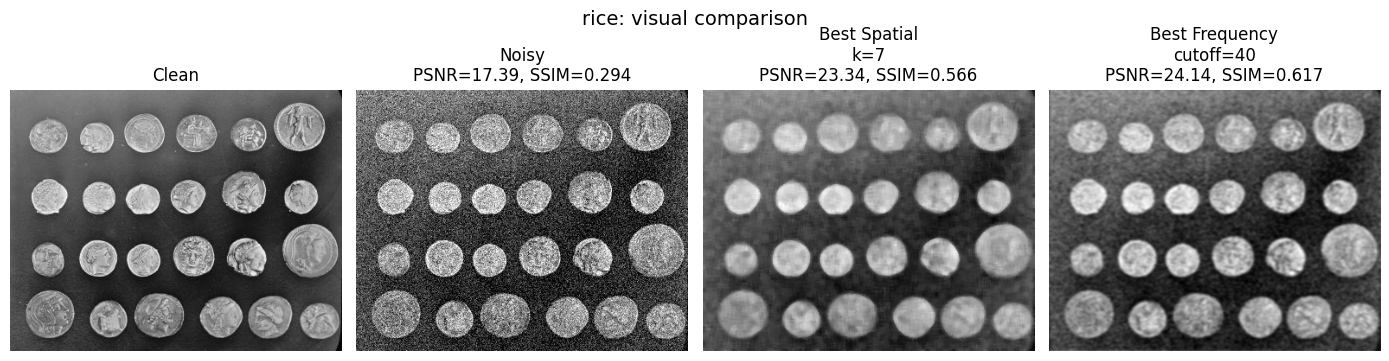


Processing image: astronaut
Spatial median, kernel=3: PSNR=30.32, SSIM=0.9375
Spatial median, kernel=5: PSNR=27.59, SSIM=0.8926
Spatial median, kernel=7: PSNR=25.71, SSIM=0.8461
Spatial median, kernel=9: PSNR=24.36, SSIM=0.8019
Frequency Gaussian, cutoff=10: PSNR=17.13, SSIM=0.4188
Frequency Gaussian, cutoff=20: PSNR=19.82, SSIM=0.5283
Frequency Gaussian, cutoff=40: PSNR=22.33, SSIM=0.6044
Frequency Gaussian, cutoff=80: PSNR=22.84, SSIM=0.5150


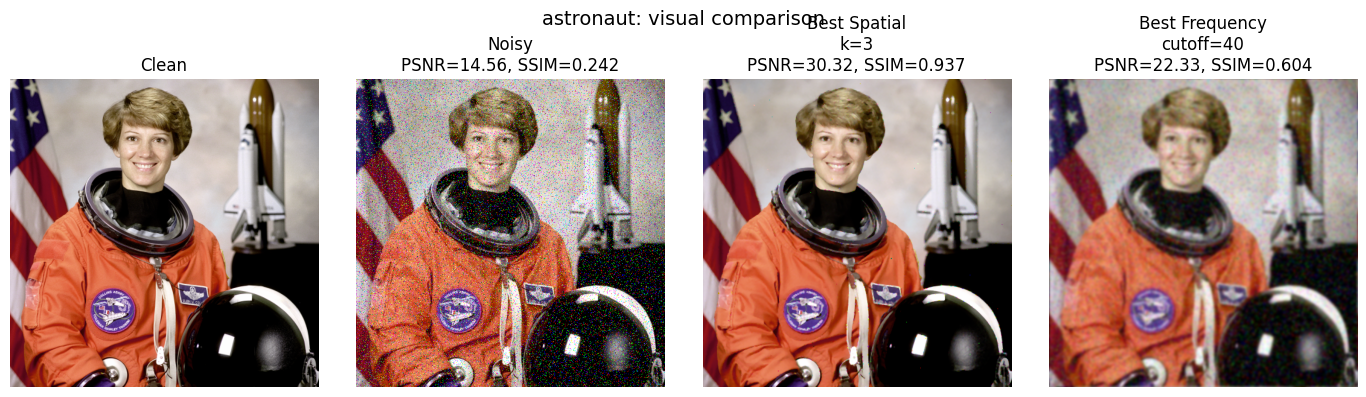

In [6]:
# -------------------------
# Parameter settings to test
# -------------------------
spatial_kernel_sizes = [3, 5, 7, 9]
frequency_cutoffs = [10, 20, 40, 80]

all_results = []
best_results = []

for name in image_names:
    clean_path = CLEAN_DIR / f"{name}.png"
    noisy_path = NOISY_DIR / f"{name}_noisy.png"

    clean = load_image(clean_path)
    noisy = load_image(noisy_path)

    print(f"\nProcessing image: {name}")

    # Baseline noisy metrics
    noisy_p, noisy_s = evaluate(clean, noisy)
    all_results.append({
        "Image": name,
        "Method": "Noisy baseline",
        "Parameters": "None",
        "PSNR": noisy_p,
        "SSIM": noisy_s
    })

    # -------------------------
    # Spatial-domain experiments
    # -------------------------
    best_spatial = None
    best_spatial_score = -1
    best_spatial_params = None
    best_spatial_metrics = None

    for k in spatial_kernel_sizes:
        denoised_spatial = spatial_denoising(
            noisy,
            method="median",
            kernel_size=k
        )

        p, s = evaluate(clean, denoised_spatial)
        print(f"Spatial median, kernel={k}: PSNR={p:.2f}, SSIM={s:.4f}")

        all_results.append({
            "Image": name,
            "Method": "Spatial Median",
            "Parameters": f"kernel={k}x{k}",
            "PSNR": p,
            "SSIM": s
        })

        # Select best result based on SSIM
        if s > best_spatial_score:
            best_spatial_score = s
            best_spatial = denoised_spatial
            best_spatial_params = k
            best_spatial_metrics = (p, s)

    # -------------------------
    # Frequency-domain experiments
    # -------------------------
    best_frequency = None
    best_frequency_score = -1
    best_frequency_params = None
    best_frequency_metrics = None

    for cutoff in frequency_cutoffs:
        denoised_frequency = frequency_gaussian_denoising(
            noisy,
            cutoff=cutoff
        )

        p, s = evaluate(clean, denoised_frequency)
        print(f"Frequency Gaussian, cutoff={cutoff}: PSNR={p:.2f}, SSIM={s:.4f}")

        all_results.append({
            "Image": name,
            "Method": "Frequency Gaussian LPF",
            "Parameters": f"cutoff={cutoff}",
            "PSNR": p,
            "SSIM": s
        })

        # Select best result based on SSIM
        if s > best_frequency_score:
            best_frequency_score = s
            best_frequency = denoised_frequency
            best_frequency_params = cutoff
            best_frequency_metrics = (p, s)

    # Store best results
    best_results.append({
        "Image": name,
        "Noise Type": noise_analysis[name]["Likely Noise Type"],
        "Spatial Best Parameters": f"median, kernel={best_spatial_params}x{best_spatial_params}",
        "Spatial PSNR": best_spatial_metrics[0],
        "Spatial SSIM": best_spatial_metrics[1],
        "Frequency Best Parameters": f"Gaussian LPF, cutoff={best_frequency_params}",
        "Frequency PSNR": best_frequency_metrics[0],
        "Frequency SSIM": best_frequency_metrics[1]
    })

    # Save best images
    save_image(RESULTS_DIR / f"{name}_best_spatial_median_k{best_spatial_params}.png", best_spatial)
    save_image(RESULTS_DIR / f"{name}_best_frequency_cutoff{best_frequency_params}.png", best_frequency)

    # -------------------------
    # Display and save visual comparison
    # -------------------------
    cmap = "gray" if len(clean.shape) == 2 else None

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(clean, cmap=cmap)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(noisy, cmap=cmap)
    plt.title(f"Noisy\nPSNR={noisy_p:.2f}, SSIM={noisy_s:.3f}")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(best_spatial, cmap=cmap)
    plt.title(f"Best Spatial\nk={best_spatial_params}\nPSNR={best_spatial_metrics[0]:.2f}, SSIM={best_spatial_metrics[1]:.3f}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(best_frequency, cmap=cmap)
    plt.title(f"Best Frequency\ncutoff={best_frequency_params}\nPSNR={best_frequency_metrics[0]:.2f}, SSIM={best_frequency_metrics[1]:.3f}")
    plt.axis("off")

    plt.suptitle(f"{name}: visual comparison", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}_comparison.png", dpi=160, bbox_inches="tight")
    plt.show()


## Part 4 - Final tables

The tables below include all parameter tuning results, the best result for each image, and the average performance across the dataset.


In [7]:
all_results_df = pd.DataFrame(all_results)
best_results_df = pd.DataFrame(best_results)

# Average performance for best selected results
average_results_df = pd.DataFrame([
    {
        "Method": "Spatial Median",
        "Average PSNR": best_results_df["Spatial PSNR"].mean(),
        "Average SSIM": best_results_df["Spatial SSIM"].mean()
    },
    {
        "Method": "Frequency Gaussian LPF",
        "Average PSNR": best_results_df["Frequency PSNR"].mean(),
        "Average SSIM": best_results_df["Frequency SSIM"].mean()
    }
])

# Save result tables
all_results_df.to_csv("all_parameter_tuning_results.csv", index=False)
best_results_df.to_csv("best_results_summary.csv", index=False)
average_results_df.to_csv("average_results.csv", index=False)

best_results_df


,Image,Noise Type,Spatial Best Parameters,Spatial PSNR,Spatial SSIM,Frequency Best Parameters,Frequency PSNR,Frequency SSIM
0,camera,Gaussian noise,"median, kernel=9x9",24.406548,0.646873,"Gaussian LPF, cutoff=40",25.037367,0.687918
1,coins,Salt-and-pepper / impulse noise,"median, kernel=3x3",28.074201,0.853591,"Gaussian LPF, cutoff=40",23.383997,0.574794
2,text,Salt-and-pepper noise,"median, kernel=3x3",32.009312,0.904324,"Gaussian LPF, cutoff=20",25.589061,0.652376
3,rice,Salt-and-pepper noise,"median, kernel=7x7",23.335817,0.565916,"Gaussian LPF, cutoff=40",24.135748,0.616753
4,astronaut,Colored salt-and-pepper / impulse noise,"median, kernel=3x3",30.317166,0.937475,"Gaussian LPF, cutoff=40",22.332432,0.604437


In [8]:
average_results_df


,Method,Average PSNR,Average SSIM
0,Spatial Median,27.628609,0.781636
1,Frequency Gaussian LPF,24.095721,0.627255


In [9]:
# Full tuning table
all_results_df


,Image,Method,Parameters,PSNR,SSIM
0,camera,Noisy baseline,None,20.419341,0.295099
1,camera,Spatial Median,kernel=3x3,25.712050,0.493907
2,camera,Spatial Median,kernel=5x5,26.213652,0.604046
3,camera,Spatial Median,kernel=7x7,25.475801,0.644166
4,camera,Spatial Median,kernel=9x9,24.406548,0.646873
5,camera,Frequency Gaussian LPF,cutoff=10,20.540157,0.571397
6,camera,Frequency Gaussian LPF,cutoff=20,22.565357,0.626830
7,camera,Frequency Gaussian LPF,cutoff=40,25.037367,0.687918
8,camera,Frequency Gaussian LPF,cutoff=80,26.944207,0.640269
9,coins,Noisy baseline,None,16.140071,0.307930


## Part 5 - Visual summary of metrics


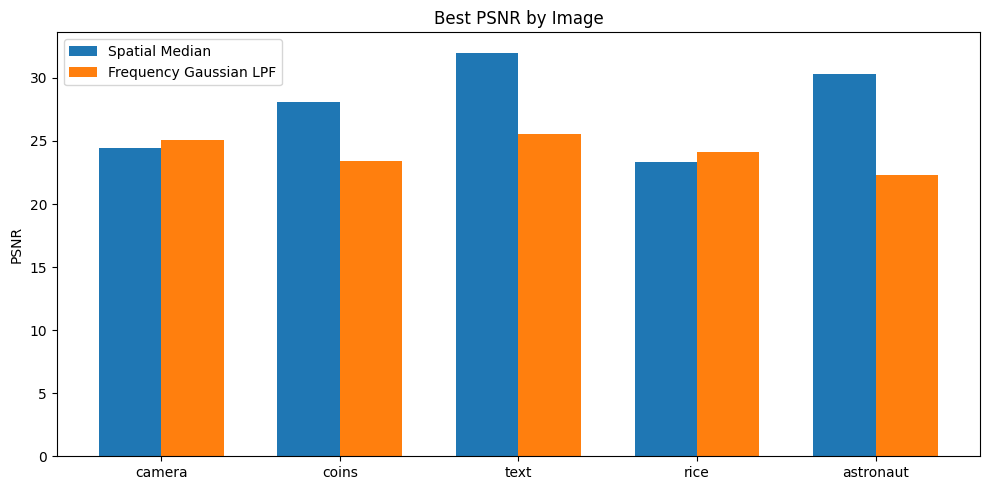

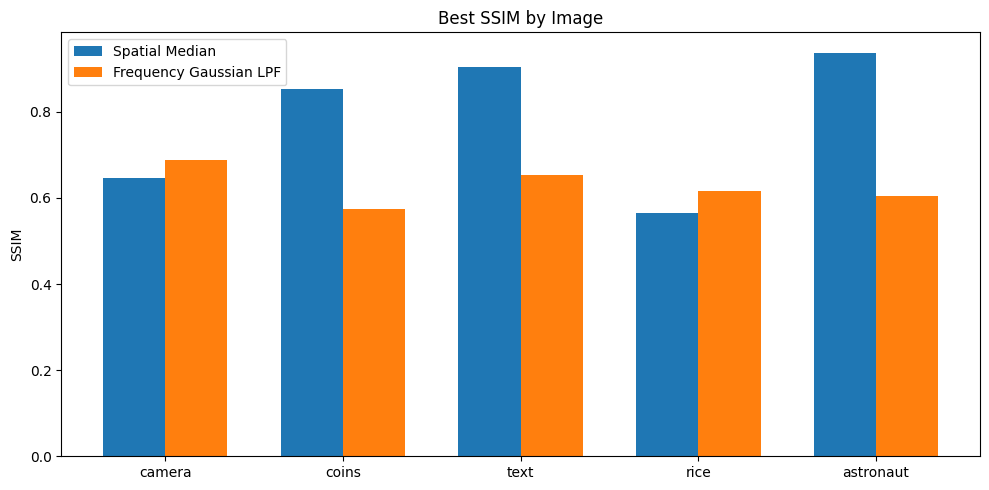

In [10]:
# Compare best PSNR and SSIM for the two methods across images
x = np.arange(len(best_results_df["Image"]))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, best_results_df["Spatial PSNR"], width, label="Spatial Median")
plt.bar(x + width/2, best_results_df["Frequency PSNR"], width, label="Frequency Gaussian LPF")
plt.xticks(x, best_results_df["Image"])
plt.ylabel("PSNR")
plt.title("Best PSNR by Image")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_psnr_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, best_results_df["Spatial SSIM"], width, label="Spatial Median")
plt.bar(x + width/2, best_results_df["Frequency SSIM"], width, label="Frequency Gaussian LPF")
plt.xticks(x, best_results_df["Image"])
plt.ylabel("SSIM")
plt.title("Best SSIM by Image")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_ssim_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


## Conclusion

Median filtering gave the strongest overall results for this dataset, especially for images with salt-and-pepper or impulse noise. The frequency-domain Gaussian low-pass filter improved some noisy images, but it also blurred edges and fine details because low-pass filtering suppresses high-frequency components. Based on the average results, the spatial median filter achieved higher PSNR and SSIM values across the full dataset.
